In [ ]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# سلول: نصب نسخه‌های سازگار
# ==========================================
!pip uninstall transformers accelerate peft -y
!pip install transformers==4.36.0
!pip install accelerate==0.25.0
!pip install peft==0.7.0


CUDA available: True
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found existing installation: transformers 4.36.0
Uninstalling transformers-4.36.0:
  Successfully uninstalled transformers-4.36.0
  Using cached transformers-4.36.0-py3-none-any.whl.metadata (126 kB)
Using cached transformers-4.36.0-py3-none-any.whl (8.2 MB)


In [2]:

# ==========================================
# سلول: تنظیمات مشترک LoRA و توابع
# ==========================================
from transformers import (RobertaForSequenceClassification,
                          RobertaTokenizer,
                          TrainingArguments,
                          EarlyStoppingCallback, Trainer)
from peft import (LoraConfig, get_peft_model, TaskType)
import torch.nn as nn
import torch.nn.functional as F
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (f1_score, accuracy_score,
                             precision_score,
                             recall_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
import os
import shutil
from collections import Counter

# ===== تنظیمات LoRA (یکسان برای هر دو مدل) =====
LORA_CONFIG = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['query', 'value','key', 'value'],
    lora_dropout=0.3,
    bias='lora_only',
    task_type=TaskType.SEQ_CLS
)

# ===== توکنایزر =====
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# ===== Data Collator =====
class MultiLabelDataCollator:
    def __init__(self, tokenizer, num_labels=28):
        self.tokenizer = tokenizer
        self.num_labels = num_labels

    def __call__(self, features):
        labels = []
        for feature in features:
            label = feature.pop("label")
            if torch.is_tensor(label):
                label = label.tolist()
            labels.append(label)

        batch_size = len(labels)
        padded_labels = torch.zeros((batch_size, self.num_labels), dtype=torch.float32)

        for i, label_list in enumerate(labels):
            for idx in label_list:
                if idx < self.num_labels:
                    padded_labels[i, idx] = 1.0

        batch = self.tokenizer.pad(features, padding=True, return_tensors="pt")
        batch["labels"] = padded_labels
        return batch

# ===== تابع محاسبه متریک‌ها =====
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = (predictions > 0.5).astype(int)

    f1_micro = f1_score(labels, predictions, average='micro', zero_division=0)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='macro', zero_division=0)
    recall = recall_score(labels, predictions, average='macro', zero_division=0)

    return {
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall
    }

# ===== Custom Logging Callback =====
from transformers import TrainerCallback

class CustomLoggingCallback(TrainerCallback):
    def __init__(self, log_steps=100):
        self.log_steps = log_steps
        self.step_count = 0
        self.train_loss_sum = 0
        self.train_loss_count = 0
        self.printed_epoch = False

    def on_step_end(self, args, state, control, **kwargs):
        self.step_count += 1
        if len(state.log_history) > 0 and 'loss' in state.log_history[-1]:
            loss = state.log_history[-1]['loss']
            self.train_loss_sum += loss
            self.train_loss_count += 1

        if self.step_count % self.log_steps == 0:
            avg_loss = self.train_loss_sum / self.train_loss_count if self.train_loss_count > 0 else 0
            lr = None
            for log in reversed(state.log_history):
                if 'learning_rate' in log:
                    lr = log['learning_rate']
                    break
            print(f"\n📊 Step {self.step_count}:")
            print(f"   Train Loss: {avg_loss:.4f}")
            if lr is not None:
                print(f"   Learning Rate: {lr:.2e}")
            self.train_loss_sum = 0
            self.train_loss_count = 0

    def on_epoch_end(self, args, state, control, **kwargs):
        if self.printed_epoch:
            return
        print(f"\n{'='*60}")
        print(f"📊 End of Epoch {state.epoch:.1f}")
        print(f"{'='*60}")

        for log in state.log_history:
            if 'eval_loss' in log and log.get('epoch', 0) == state.epoch:
                print(f"\n   📈 Validation Metrics:")
                print(f"   Validation Loss: {log['eval_loss']:.4f}")
                print(f"   F1-Macro: {log.get('eval_f1_macro', 0):.4f}")
                print(f"   F1-Micro: {log.get('eval_f1_micro', 0):.4f}")
                print(f"   Accuracy: {log.get('eval_accuracy', 0):.4f}")
                print(f"   Precision: {log.get('eval_precision_macro', 0):.4f}")
                print(f"   Recall: {log.get('eval_recall_macro', 0):.4f}")
                break
        print(f"{'='*60}\n")
        self.printed_epoch = True

print("✅ Shared configurations loaded!")


/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


RuntimeError: Failed to import transformers.trainer because of the following error (look up to see its traceback):
cannot import name 'EncoderDecoderCache' from 'transformers' (/usr/local/lib/python3.13/dist-packages/transformers/__init__.py)

In [7]:
# ==========================================
# سلول: کپی و اکسترکت دیتاست از Drive به Colab
# ==========================================
import zipfile

drive_zip_path = "/content/drive/MyDrive/tokenized.zip"

!cp "{drive_zip_path}" "/content/tokenized.zip"
print("✅ فایل ZIP به Colab کپی شد!")

with zipfile.ZipFile("/content/tokenized.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/tokenized")
print("✅ دیتاست در /content/tokenized/ اکسترکت شد!")

print("\n📁 محتویات پوشه tokenized:")
!ls -la /content/tokenized/

✅ فایل ZIP به Colab کپی شد!
✅ دیتاست در /content/tokenized/ اکسترکت شد!

📁 محتویات پوشه tokenized:
total 12
drwxr-xr-x 3 root root 4096 Aug 23 19:26 .
drwxr-xr-x 1 root root 4096 Aug 23 19:26 ..
drwxr-xr-x 5 root root 4096 Aug 23 19:26 tokenized


In [8]:
# ==========================================
# سلول: بارگذاری دیتاست اصلی با pyarrow
# ==========================================
import os
import pyarrow.ipc as ipc
import pandas as pd
from datasets import Dataset, DatasetDict

print("🔄 Loading original dataset with pyarrow...")

# مسیر دیتاست (پس از اکسترکت)
data_path = '/content/tokenized/tokenized'

def read_arrow_file(file_path):
    with open(file_path, 'rb') as f:
        reader = ipc.open_stream(f)
        table = reader.read_all()
        return table.to_pandas()

# بارگذاری
train_df = read_arrow_file(os.path.join(data_path, 'train/data-00000-of-00001.arrow'))
val_df = read_arrow_file(os.path.join(data_path, 'validation/data-00000-of-00001.arrow'))
test_df = read_arrow_file(os.path.join(data_path, 'test/data-00000-of-00001.arrow'))

tokenized_data_original = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
})

print("✅ Original dataset loaded successfully!")
print(f"   Train samples: {len(tokenized_data_original['train'])}")
print(f"   Validation samples: {len(tokenized_data_original['validation'])}")
print(f"   Test samples: {len(tokenized_data_original['test'])}")

🔄 Loading original dataset with pyarrow...
✅ Original dataset loaded successfully!
   Train samples: 43410
   Validation samples: 5426
   Test samples: 5427


📊 ORIGINAL DATASET ANALYSIS

📌 General Statistics:
   Total samples: 51,103
   Number of classes: 28
   Average samples per class: 1825.1
   Min samples in a class: 77
   Max samples in a class: 14219
   Imbalance Ratio (max/min): 184.66

🎯 Classes with < 1000 samples: 10 classes
   Class 16:    77 samples
   Class 21:   111 samples
   Class 23:   153 samples
   Class 19:   164 samples
   Class 12:   303 samples
   Class 24:   545 samples
   Class 14:   596 samples
   Class  8:   641 samples
   Class 11:   793 samples
   Class 13:   853 samples


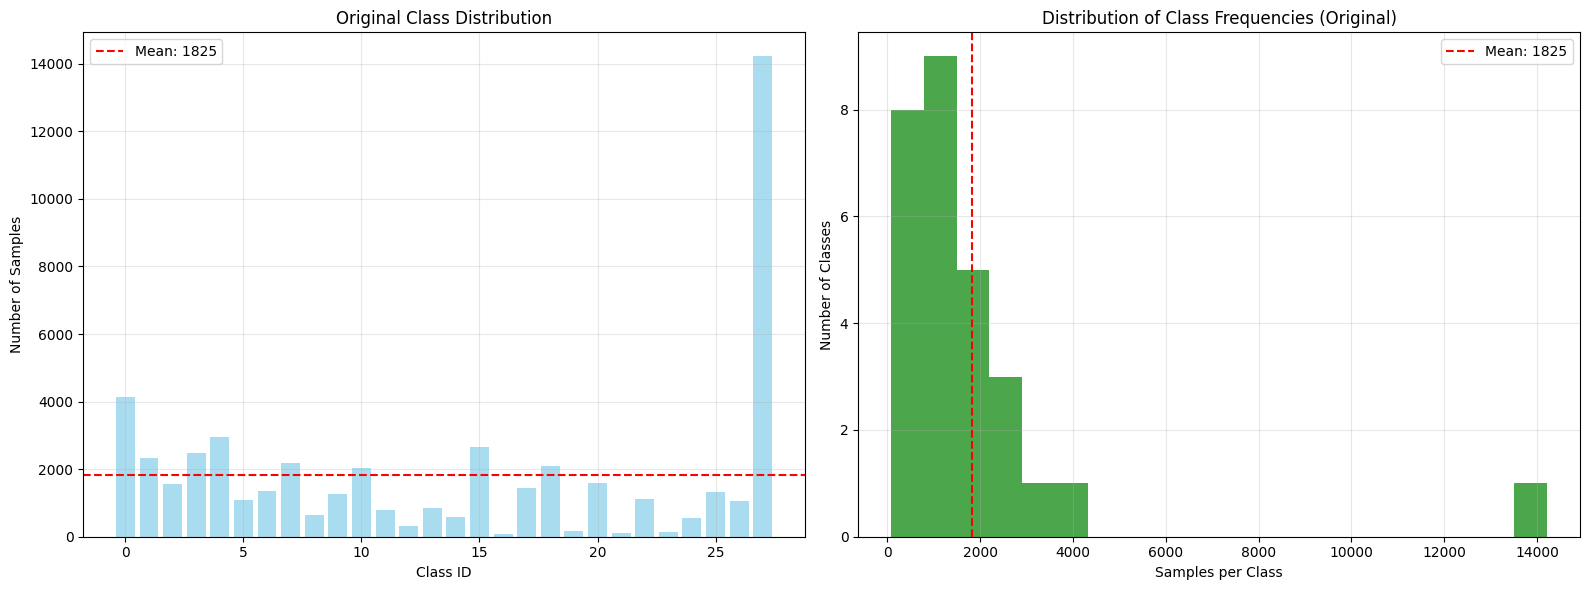

✅ Original dataset analysis completed!


In [10]:
# ==========================================
# سلول: تحلیل کامل دیتاست اصلی (اصلاح‌شده)
# ==========================================
# استخراج برچسب‌ها
all_labels_original = []
for item in tokenized_data_original['train']:
    label = item['label']
    if torch.is_tensor(label):
        label = label.tolist()
    all_labels_original.extend(label)

label_counts_original = Counter(all_labels_original)
total_samples_original = len(all_labels_original)

print("=" * 60)
print("📊 ORIGINAL DATASET ANALYSIS")
print("=" * 60)

print(f"\n📌 General Statistics:")
print(f"   Total samples: {total_samples_original:,}")
print(f"   Number of classes: {len(label_counts_original)}")
print(f"   Average samples per class: {total_samples_original / len(label_counts_original):.1f}")
print(f"   Min samples in a class: {min(label_counts_original.values())}")
print(f"   Max samples in a class: {max(label_counts_original.values())}")

# نسبت نامتوازنی
imbalance_ratio_original = max(label_counts_original.values()) / min(label_counts_original.values())
print(f"   Imbalance Ratio (max/min): {imbalance_ratio_original:.2f}")

# ===== کلاس‌های با کمتر از ۱۰۰۰ نمونه (اصلاح‌شده) =====
# درست: list of tuples (class_id, count)
target_classes = [(c, count) for c, count in label_counts_original.items() if count < 1000]
print(f"\n🎯 Classes with < 1000 samples: {len(target_classes)} classes")
for c, count in sorted(target_classes, key=lambda x: x[1]):  # ← مرتب‌سازی بر اساس تعداد نمونه
    print(f"   Class {c:2d}: {count:>5} samples")

# ===== اگر فقط لیست کلاس‌ها را نیاز دارید (برای داده‌افزایی) =====
target_class_ids = [c for c, count in target_classes]  # ← فقط شناسه کلاس‌ها

# رسم نمودار توزیع کلاس‌ها
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_ids = sorted(label_counts_original.keys())
frequencies = [label_counts_original[c] for c in class_ids]

axes[0].bar(class_ids, frequencies, color='skyblue', alpha=0.7)
axes[0].axhline(y=total_samples_original/len(label_counts_original), color='red', linestyle='--',
                label=f'Mean: {total_samples_original/len(label_counts_original):.0f}')
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Original Class Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(frequencies, bins=20, color='green', alpha=0.7)
axes[1].axvline(x=total_samples_original/len(label_counts_original), color='red', linestyle='--',
                label=f'Mean: {total_samples_original/len(label_counts_original):.0f}')
axes[1].set_xlabel('Samples per Class')
axes[1].set_ylabel('Number of Classes')
axes[1].set_title('Distribution of Class Frequencies (Original)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/original_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Original dataset analysis completed!")

In [ ]:
# ==========================================
# سلول: نصب نسخه‌های کاملاً سازگار
# ==========================================
!pip uninstall nlpaug transformers -y
!pip install transformers==4.36.0
!pip install nlpaug==1.1.10
!pip install tokenizers==0.15.0

import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ All libraries installed with compatible versions!")

# ==========================================
# سلول: داده‌افزایی هدفمند
# ==========================================
import nlpaug.augmenter.word as naw
import random
import torch
import os
from datasets import Dataset, DatasetDict
from transformers import RobertaTokenizer
from collections import Counter
import shutil

print("🔄 Starting targeted augmentation...")

# ===== توکنایزر =====
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# ===== روش‌های داده‌افزایی =====
augmenters = [
    naw.SynonymAug(aug_src='wordnet', aug_p=0.50),
    naw.ContextualWordEmbsAug(
        model_path='roberta-base',
        action="substitute",
        aug_p=0.50
    ),
]

def intelligent_augmentation(text, num_augmentations=2):
    augmented_texts = []
    for _ in range(num_augmentations):
        aug_method = random.choice(augmenters)
        try:
            new_text = aug_method.augment(text)
            if len(new_text.strip()) > 0 and new_text != text:
                augmented_texts.append(new_text)
        except Exception as e:
            continue
    return augmented_texts

# ===== اطمینان از تعریف target_classes =====
# اگر target_classes لیست تاپل است، آن را به لیست کلاس‌ها تبدیل کنید
if 'target_classes' in dir():
    if isinstance(target_classes[0], tuple):
        target_class_ids = [c for c, count in target_classes]
    else:
        target_class_ids = target_classes
else:
    target_class_ids = [c for c, count in label_counts_original.items() if count < 1000]

print(f"🎯 Target classes: {target_class_ids}")

# ===== تولید نمونه‌های جدید =====
all_new_samples = []

for class_id in target_class_ids:
    # استخراج نمونه‌های کلاس هدف
    class_samples = []
    for item in tokenized_data_original['train']:
        label = item['label']
        if torch.is_tensor(label):
            label = label.tolist()
        if class_id in label:
            class_samples.append(item)

    current_count = len(class_samples)
    target_count = 1000
    needed = target_count - current_count
    per_sample = max(1, needed // current_count) if current_count > 0 else 1

    print(f"\n🔄 Augmenting class {class_id}: {current_count} → {target_count} (+{needed})")

    new_samples = []
    for item in class_samples:
        text = tokenizer.decode(item['input_ids'], skip_special_tokens=True)
        augmented_texts = intelligent_augmentation(text, num_augmentations=per_sample)

        for aug_text in augmented_texts:
            new_inputs = tokenizer(
                aug_text,
                padding='max_length',
                truncation=True,
                max_length=128,
                return_tensors='pt'
            )
            new_samples.append({
                'input_ids': new_inputs['input_ids'].squeeze(0),
                'attention_mask': new_inputs['attention_mask'].squeeze(0),
                'label': item['label']
            })
            if len(new_samples) >= needed:
                break
        if len(new_samples) >= needed:
            break

    new_samples = new_samples[:needed]
    all_new_samples.extend(new_samples)
    print(f"   ✅ Added {len(new_samples)} samples for class {class_id}")

# ===== اضافه کردن به دیتاست =====
if all_new_samples:
    new_dataset = Dataset.from_list(all_new_samples)
    combined_train = Dataset.from_list(
        list(tokenized_data_original['train']) + list(new_dataset)
    )

    tokenized_data_augmented = DatasetDict({
        'train': combined_train,
        'validation': tokenized_data_original['validation'],
        'test': tokenized_data_original['test']
    })
    print(f"\n✅ Augmented dataset created!")
    print(f"   New train size: {len(combined_train)} samples")
    print(f"   Added {len(all_new_samples)} new samples")
else:
    tokenized_data_augmented = tokenized_data_original
    print("⚠️ No new samples created")

# ===== ذخیره دیتاست جدید در Drive =====
tokenized_data_augmented.save_to_disk("/content/tokenized_augmented")
if os.path.exists("/content/drive/MyDrive/tokenized_augmented"):
    shutil.rmtree("/content/drive/MyDrive/tokenized_augmented")
shutil.copytree("/content/tokenized_augmented", "/content/drive/MyDrive/tokenized_augmented")
print("✅ Augmented dataset saved to Drive!")

Found existing installation: nlpaug 1.1.11
Uninstalling nlpaug-1.1.11:
  Successfully uninstalled nlpaug-1.1.11
Found existing installation: transformers 5.15.0
Uninstalling transformers-5.15.0:
  Successfully uninstalled transformers-5.15.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 110.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.27.0
    Uninstalling huggingface_hub-1.27.0:
      Successfully uninstalled huggingface_hub-1.27.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.8/410.8 kB 20.1 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.5/318.5 kB 14.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... canceled
ERROR: Operation cancelled by user
^C


In [ ]:
# ==========================================
# سلول: تحلیل دیتاست جدید و مقایسه با اصلی
# ==========================================
# استخراج برچسب‌های دیتاست جدید
all_labels_augmented = []
for item in tokenized_data_augmented['train']:
    label = item['label']
    if torch.is_tensor(label):
        label = label.tolist()
    all_labels_augmented.extend(label)

label_counts_augmented = Counter(all_labels_augmented)

print("=" * 60)
print("📊 COMPARISON: Original vs Augmented Dataset")
print("=" * 60)

print(f"\n📌 General Statistics:")
print(f"   Original total: {len(all_labels_original):,}")
print(f"   Augmented total: {len(all_labels_augmented):,}")
print(f"   Increase: {len(all_labels_augmented) - len(all_labels_original):,} samples")

print("\n📊 Per-class changes (target classes):")
for class_id in sorted(target_classes):
    before = label_counts_original.get(class_id, 0)
    after = label_counts_augmented.get(class_id, 0)
    change = after - before
    percent = (change / before * 100) if before > 0 else 0
    print(f"   Class {class_id:2d}: {before:>5} → {after:>5} (+{change:>4}, {percent:>6.1f}%)")

# محاسبه وزن کلاس‌های جدید (برای مدل A)
unique_labels_aug = np.unique(all_labels_augmented)
class_weights_aug = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels_aug,
    y=all_labels_augmented
)
class_weight_dict_aug = {int(label): weight for label, weight in zip(unique_labels_aug, class_weights_aug)}

# رسم نمودار مقایسه‌ای
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

class_ids_comp = sorted(set(label_counts_original.keys()) | set(label_counts_augmented.keys()))
before_vals = [label_counts_original.get(c, 0) for c in class_ids_comp]
after_vals = [label_counts_augmented.get(c, 0) for c in class_ids_comp]

x = np.arange(len(class_ids_comp))
width = 0.35

axes[0].bar(x - width/2, before_vals, width, label='Original', color='lightcoral', alpha=0.7)
axes[0].bar(x + width/2, after_vals, width, label='Augmented', color='lightgreen', alpha=0.7)
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Comparison: Original vs Augmented')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

changes = [(after - before) / before * 100 if before > 0 else 0 for before, after in zip(before_vals, after_vals)]
axes[1].bar(class_ids_comp, changes, color='steelblue', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Percent Change (%)')
axes[1].set_title('Percentage Increase per Class')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison completed!")


In [ ]:
print("\n🔄 Loading base model from Google Drive...")

# مسیر مدل پایه در Drive
model_path = "/content/drive/MyDrive/roberta-base-classification"

base_model = RobertaForSequenceClassification.from_pretrained(
    model_path,
    num_labels=28,
    ignore_mismatched_sizes=True
)
print('✅ Base model loaded successfully from Google Drive!')


In [ ]:
# ==========================================
# سلول: آموزش مدل A (پیشرفته)
# ==========================================
print("=" * 60)
print("🚀 TRAINING MODEL A (Advanced - Class Weights + Focal Loss + Augmented Data)")
print("=" * 60)

# ===== ۱. اعمال LoRA روی مدل پایه =====
model_A = get_peft_model(base_model, LORA_CONFIG)
print("✅ LoRA applied to Model A")

# ===== ۲. وزن کلاس‌ها از دیتاست داده‌افزایی‌شده =====
class_weights_list_A = [class_weight_dict_aug.get(i, 1.0) for i in range(28)]

# ===== ۳. Focal Loss =====
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return focal_loss.mean()

class FocalLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32)

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = FocalLoss(alpha=0.25, gamma=2.0)
        loss = loss_fct(logits * self.class_weights.to(logits.device), labels)

        return (loss, outputs) if return_outputs else loss

# ===== ۴. Training Arguments =====
training_args_A = TrainingArguments(
    output_dir="/content/drive/MyDrive/emotion_model_checkpoints_A",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=1e-4,
    weight_decay=0.15,
    warmup_steps=500,
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=5,
    fp16=True,
    label_smoothing_factor=0.25,
    report_to="none",
    logging_strategy="steps",
    logging_steps=100,
)

# ===== ۵. Trainer A =====
trainer_A = FocalLossTrainer(
    class_weights=class_weights_list_A,
    model=model_A,
    args=training_args_A,
    train_dataset=tokenized_data_augmented['train'],
    eval_dataset=tokenized_data_augmented['validation'],
    compute_metrics=compute_metrics,
    data_collator=MultiLabelDataCollator(tokenizer, num_labels=28),
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        CustomLoggingCallback(log_steps=100)
    ]
)

print("✅ Trainer A ready!")
trainer_A.train()
print("✅ Model A training completed!")

# ===== ۶. ارزیابی مدل A =====
test_results_A = trainer_A.evaluate(tokenized_data_augmented['test'])
print("\n📊 MODEL A TEST RESULTS")
print(f"   Loss:      {test_results_A['eval_loss']:.4f}")
print(f"   F1-Macro:  {test_results_A['eval_f1_macro']:.4f}")
print(f"   F1-Micro:  {test_results_A['eval_f1_micro']:.4f}")
print(f"   Accuracy:  {test_results_A['eval_accuracy']:.4f}")

In [ ]:
# ==========================================
# سلول: آموزش مدل B (ساده)
# ==========================================
print("=" * 60)
print("🚀 TRAINING MODEL B (Baseline - No Weights, No Focal Loss, Original Data)")
print("=" * 60)

# ===== ۱. اعمال LoRA روی مدل پایه =====
model_B = get_peft_model(base_model, LORA_CONFIG)
print("✅ LoRA applied to Model B")

# ===== ۲. Training Arguments =====
training_args_B = TrainingArguments(
    output_dir="/content/drive/MyDrive/emotion_model_checkpoints_B",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=500,
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=3,
    fp16=True,
    report_to="none",
    logging_steps=100,
)

# ===== ۳. Trainer B (معمولی، بدون Focal Loss) =====
trainer_B = Trainer(
    model=model_B,
    args=training_args_B,
    train_dataset=tokenized_data_original['train'],
    eval_dataset=tokenized_data_original['validation'],
    compute_metrics=compute_metrics,
    data_collator=MultiLabelDataCollator(tokenizer, num_labels=28),
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        CustomLoggingCallback(log_steps=100)
    ]
)

print("✅ Trainer B ready!")
trainer_B.train()
print("✅ Model B training completed!")

# ===== ۴. ارزیابی مدل B =====
test_results_B = trainer_B.evaluate(tokenized_data_original['test'])
print("\n📊 MODEL B TEST RESULTS")
print(f"   Loss:      {test_results_B['eval_loss']:.4f}")
print(f"   F1-Macro:  {test_results_B['eval_f1_macro']:.4f}")
print(f"   F1-Micro:  {test_results_B['eval_f1_micro']:.4f}")
print(f"   Accuracy:  {test_results_B['eval_accuracy']:.4f}")


In [ ]:
# ==========================================
# سلول: مقایسه نهایی دو مدل
# ==========================================
print("=" * 60)
print("📊 FINAL COMPARISON: Model A vs Model B")
print("=" * 60)

# ===== جدول مقایسه =====
comparison_df = pd.DataFrame({
    'Metric': ['Loss', 'F1-Macro', 'F1-Micro', 'Accuracy', 'Precision', 'Recall'],
    'Model A (Advanced)': [
        test_results_A['eval_loss'],
        test_results_A['eval_f1_macro'],
        test_results_A['eval_f1_micro'],
        test_results_A['eval_accuracy'],
        test_results_A.get('eval_precision_macro', 0),
        test_results_A.get('eval_recall_macro', 0)
    ],
    'Model B (Baseline)': [
        test_results_B['eval_loss'],
        test_results_B['eval_f1_macro'],
        test_results_B['eval_f1_micro'],
        test_results_B['eval_accuracy'],
        test_results_B.get('eval_precision_macro', 0),
        test_results_B.get('eval_recall_macro', 0)
    ],
    'Improvement': [
        test_results_B['eval_loss'] - test_results_A['eval_loss'],
        test_results_A['eval_f1_macro'] - test_results_B['eval_f1_macro'],
        test_results_A['eval_f1_micro'] - test_results_B['eval_f1_micro'],
        test_results_A['eval_accuracy'] - test_results_B['eval_accuracy'],
        test_results_A.get('eval_precision_macro', 0) - test_results_B.get('eval_precision_macro', 0),
        test_results_A.get('eval_recall_macro', 0) - test_results_B.get('eval_recall_macro', 0)
    ]
})

print("\n📊 Comparison Table:")
print(comparison_df.to_string(index=False))

# ===== رسم نمودار مقایسه‌ای =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['F1-Macro', 'F1-Micro', 'Accuracy', 'Precision', 'Recall']
values_A = [test_results_A['eval_f1_macro'], test_results_A['eval_f1_micro'],
            test_results_A['eval_accuracy'], test_results_A.get('eval_precision_macro', 0),
            test_results_A.get('eval_recall_macro', 0)]
values_B = [test_results_B['eval_f1_macro'], test_results_B['eval_f1_micro'],
            test_results_B['eval_accuracy'], test_results_B.get('eval_precision_macro', 0),
            test_results_B.get('eval_recall_macro', 0)]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, values_A, width, label='Model A (Advanced)', color='green', alpha=0.7)
axes[0].bar(x + width/2, values_B, width, label='Model B (Baseline)', color='red', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# نمودار بهبود
improvements = comparison_df['Improvement'].values[:5]
axes[1].bar(metrics, improvements, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Improvement (A - B)')
axes[1].set_title('Improvement of Model A over Model B')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== ماتریس درهم‌ریختگی =====
def plot_confusion_matrix(trainer, dataset, title, save_path):
    predictions_output = trainer.predict(dataset)
    predictions = (predictions_output.predictions > 0.5).astype(int)
    true_labels = predictions_output.label_ids

    pred_single = np.argmax(predictions, axis=1)
    true_single = np.argmax(true_labels, axis=1)

    cm = confusion_matrix(true_single, pred_single)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(28))
    disp.plot(cmap='Blues', xticks_rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ===== ماتریس برای مدل A =====
print("\n📊 Confusion Matrix - Model A")
plot_confusion_matrix(
    trainer_A,
    tokenized_data_augmented['test'],
    'Confusion Matrix - Model A (Advanced)',
    '/content/drive/MyDrive/confusion_matrix_A.png'
)

# ===== ماتریس برای مدل B =====
print("\n📊 Confusion Matrix - Model B")
plot_confusion_matrix(
    trainer_B,
    tokenized_data_original['test'],
    'Confusion Matrix - Model B (Baseline)',
    '/content/drive/MyDrive/confusion_matrix_B.png'
)

print("\n✅ All results saved to Drive!")
